In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# Satıcılar

🎯 Amacımız, diğerlerine göre tekrarlı olarak düşük performans gösteren satıcıları bulmak ve nedenini anlamaktır.  
Bu, Olist'in gelecekte kâr marjını artırmaya yönelik önerilerimizi şekillendirmemize yardımcı olacaktır.

## 1 - `olist/seller.py`  

`order.py` ile benzer bir süreçte, size `olist/seller.py` modülünü sunduk; içinde `Seller` sınıfı ve `Seller().get_training_data` yöntemi bulunuyor. Bu yöntem aşağıdaki özellikleri içeren bir DataFrame döndürür:

| feature_name | type | açıklama |
| --- | --- | --- |
| `seller_id` | str | satıcının benzersiz kimliği (UNIQUE) |
| `seller_city` | str | satıcının bulunduğu şehir |
| `seller_state` | str | satıcının bulunduğu eyalet |
| `delay_to_carrier` | float | sipariş, `shipping_limit_date`'den önce teslim edildiyse 0 döner; aksi takdirde gecikme süresini verir |
| `wait_time` | float | satıcı başına ortalama teslimat süresi (bekleme süresi) |
| `date_first_sale` | datetime | Olist üzerinde yapılan ilk satışın tarihi |
| `date_last_sale` | datetime | Olist üzerindeki son satışın tarihi |
| `months_on_olist` | float | Olist'te geçirilen yaklaşık ay sayısı |
| `share_of_five_stars` | float | satıcının yer aldığı siparişlerdeki beş yıldız değerlendirmelerinin oranı |
| `share_of_one_stars` | float | satıcının yer aldığı siparişlerdeki bir yıldız değerlendirmelerinin oranı |
| `review_score` | float | satıcının yer aldığı siparişler için ortalama değerlendirme puanı |
| `n_orders` | int | satıcının yer aldığı benzersiz sipariş sayısı |
| `quantity` | int | bu satıcı tarafından satılan toplam ürün adedi |
| `quantity_per_order` | float | bu satıcı için sipariş başına ortalama ürün sayısı |
| `sales` | float | bu satıcı ile ilişkili toplam satış tutarı (kargo hariç), BRL cinsinden |

❓ **Aşağıya yeni sınıfınızı import edin ve eğitim veri çerçevenizi inceleyin!** Kodları incelemek için zaman ayırın ve sizin için tam olarak nelerin hesaplandığını anlayın.

In [2]:
# YOUR CODE HERE
from olist.order import Order
orders = Order().get_training_data(with_distance_seller_customer=True)

🤔 Her satıcı için henüz hesaplanması gereken bir şey kaldı:
- Aşırı yüksek değerlendirmelerin oranı (`share_of_five_stars`) ve aşırı düşük değerlendirmelerin oranı (`share_of_one_stars`)
- (ortalama) `review_score`

😱 Düşük puanlı her sipariş Olist'in itibarına olumsuz etki yapar; bu etki `cost_of_review` ile modellenir.

Bu, daha sonra her satıcı için toplam `cost_of_review`'u hesaplamamıza yardımcı olacak!

❓ **Sizin doldurmanız gereken son metod: `get_review_score()`'u implemente edin.**

In [14]:
# YOUR CODE HERE
from olist.seller import Seller
seller = Seller()
sellers = seller.get_training_data()
sellers.shape

(2967, 15)

In [8]:
Seller.get_review_score??

Signature: Seller.get_review_score(self)
Source:   
    def get_review_score(self):
        """
        Returns a DataFrame with:
        'seller_id', 'share_of_five_stars', 'share_of_one_stars', 'review_score'
        """

        pass  # YOUR CODE HERE
File:      ~/Desktop/WT/data-context-and-setup/olist/seller.py
Type:      function

In [9]:
Seller.__init__??

Signature: Seller.__init__(self)
Docstring: Initialize self.  See help(type(self)) for accurate signature.
Source:   
    def __init__(self):
        # Import data only once
        olist = Olist()
        self.data = olist.get_data()
        self.order = Order()
File:      ~/Desktop/WT/data-context-and-setup/olist/seller.py
Type:      function

🧪 Kodunuzu aşağıda test edin

In [15]:
from nbresult import ChallengeResult

tmp = Seller().get_training_data()
result = ChallengeResult('seller',
    shape = tmp.shape,
    median = tmp.review_score.median(),
    columns = tmp.columns
)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.7, pytest-9.0.3, pluggy-1.6.0 -- /opt/anaconda3/bin/python
cachedir: .pytest_cache
rootdir: /Users/simgecevik/Desktop/WT/data-sellers/tests
plugins: dash-4.4.1, anyio-4.2.0
collecting ... collected 3 items

test_seller.py::TestSeller::test_column_names PASSED                     [ 33%]
test_seller.py::TestSeller::test_median_review_score PASSED              [ 66%]
test_seller.py::TestSeller::test_shape PASSED                            [100%]

============================== 3 passed in 0.59s ===============================


💯 You can commit your code:

git add tests/seller.pickle

git commit -m 'Completed seller step'

git push origin master



💡 **Tam satır sayısını elde edemiyor musunuz?**
<details><summary>Fazladan 3 satır mı var?</summary>
Left veya right join mi yaptınız? Nedenini anlıyoruz; fakat burada sadece değerlendirme alan satıcılarla ilgileniyoruz; bu yüzden inner join kullandık.
</details>
<details><summary>2 satır mı eksik?</summary>
`Orders().get_training_data()`'ı mı kullandınız? Bu geçerli bir seçenek, fakat sadece değerlendirmelerle ilgileniyorsak biraz aşırı olabilir. O method birçok hesaplama yapar ve döndürdüğü sütunların çoğuna ihtiyaç duymuyoruz. İhtiyacımıza daha uygun başka bir `Order` methodu bulun.
</details>

⚠️ `olist` reposundaki `seller.py` dosyasına yaptığınız kod değişikliklerini commit etmeyi unutmayın!

## 2 - Satıcıları İnceleme

### (2.1) Görselleştirmeler

Bu satıcılar hakkında ilk ***`EDA - Keşifsel Veri Analizi`*** ile başlayalım.

👉 `sellers` için özet istatistiklere bakın. Satıcı başına siparişlerin medyanı nedir ❓

In [16]:
# YOUR CODE HERE
sellers.describe()

,delay_to_carrier,wait_time,date_first_sale,date_last_sale,months_on_olist,n_orders,quantity,quantity_per_order,sales,share_of_five_stars,share_of_one_stars,review_score
count,2967.000000,2967.000000,2967,2967,2967.000000,2967.000000,2967.000000,2967.000000,2967.000000,2967.000000,2967.000000,2967.000000
mean,0.385636,12.139417,2017-10-23 20:09:55.342096,2018-04-25 09:37:50.292551,6.116616,33.650489,37.897203,1.157337,4568.852187,0.595077,0.120886,4.101513
min,0.000000,1.214178,2016-09-15 12:16:38,2016-10-06 15:44:56,0.000000,1.000000,1.000000,1.000000,6.500000,0.000000,0.000000,1.000000
25%,0.000000,8.287658,2017-04-25 08:04:06.500000,2018-02-13 09:27:30,1.000000,2.000000,3.000000,1.000000,239.850000,0.493022,0.000000,3.846154
50%,0.000000,11.115143,2017-11-09 18:35:42,2018-07-19 14:30:17,4.000000,7.000000,8.000000,1.000000,896.000000,0.600000,0.058824,4.210526
75%,0.000000,14.231984,2018-04-24 18:21:19,2018-08-17 08:35:23,10.000000,23.000000,26.000000,1.142857,3583.995000,0.750000,0.159043,4.626453
max,45.434039,189.863160,2018-08-28 09:44:14,2018-09-03 17:40:06,23.000000,1854.000000,2033.000000,15.000000,229472.630000,1.000000,1.000000,5.000000
std,2.295812,7.069233,NaN,NaN,6.085524,107.182856,121.514362,0.439557,14191.836779,0.278763,0.188857,0.801517


👉 Bir sonraki adımda, veri setindeki her sayısal değişkenin dağılımını tek bir büyük görselde çizeceğiz. 

Kod size verildi, hücreyi çalıştırmanız yeterli.

- 👀 Herhangi bir aykırı değer fark ediyor musunuz?
- Sipariş sayısının dağılımı nasıl görünüyor ❓

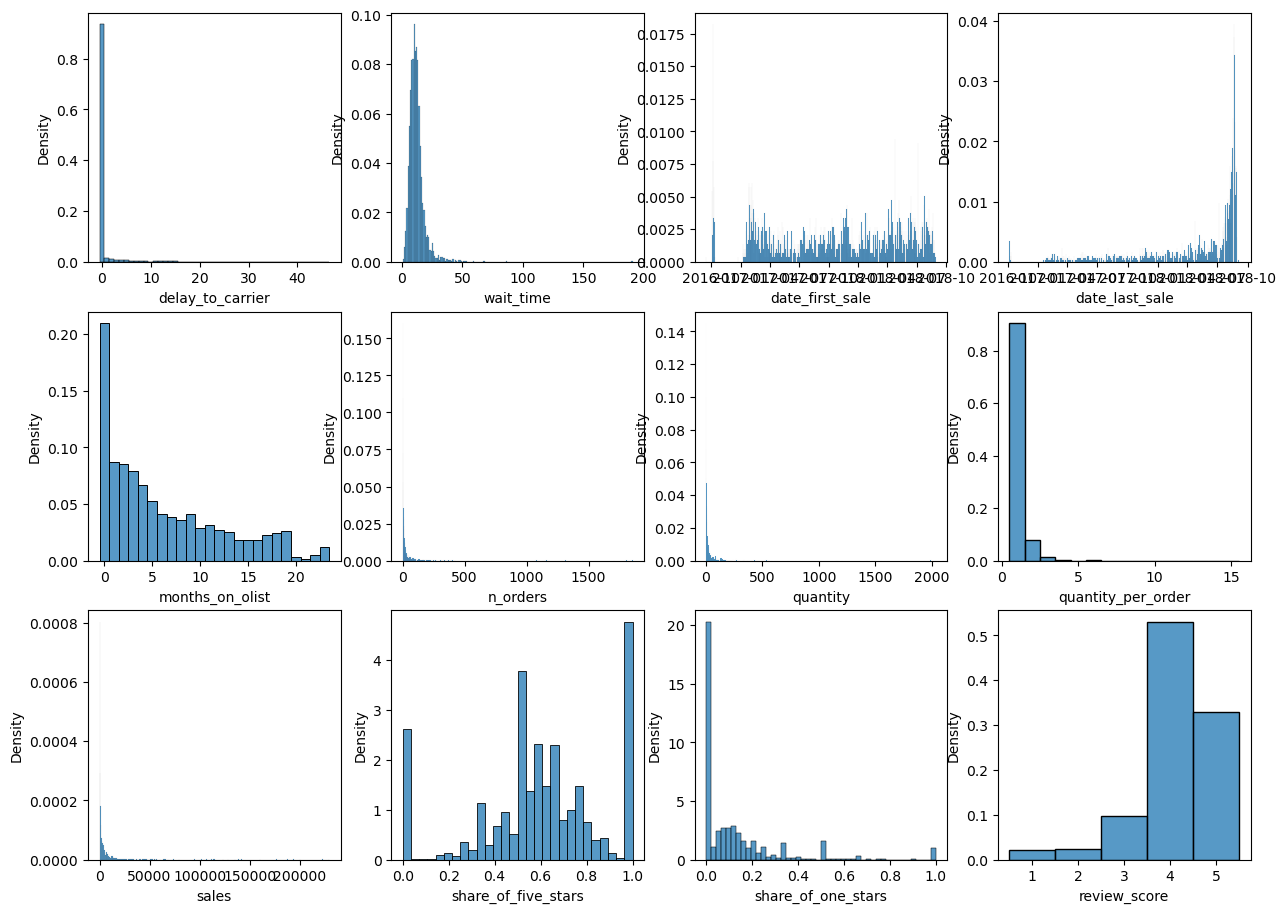

In [18]:
plt.figure(figsize=(15,11))
for (i, col) in enumerate(sellers.describe().columns):#["wait_time", "delay_to_carrier", "avg_review_score", "n_orders", "quantity", "price"]):
    plt.subplot(3,4,i+1)
    sns.histplot(sellers[col], kde=False, stat='density', discrete=[True,None][col in ['share_of_one_stars','share_of_five_stars','sales']]);

💡 Çok düşük değerlendirme puanlarına sahip bir grup satıcının öne çıktığı görünüyor!

📊 Grafiksel olarak inceleyelim:
- `plotly` kullanarak `delay_to_carrier` ile `wait_time` arasındaki ilişkiyi gösteren bir saçılma grafiği (scatterplot) oluşturuyoruz; kabarcık boyutunu satıcının toplam `sales`'i, rengini ise `review_score` belirliyor.

`plotly`'ı daha sonra detaylı göreceğiz; şimdilik aşağıdaki hücreyi çalıştırın.

In [19]:
import plotly.express as px
fig = px.scatter(data_frame = sellers[sellers['review_score'] < 4],
    x="wait_time",
    y="delay_to_carrier",
    size="sales",
    color="review_score",
    size_max = 60,
    opacity = 0.5
)
fig.show()

En kötü satıcıları bulmak için `x`, `y`, `color` ve `size` değerlerini değiştirmekten çekinmeyin.

### (2.2) `review_score`'u OLS ile modelleme

⚠️ Saçılma grafikleri veriyi görsel olarak analiz etmemizi sağlar, fakat sınırlamaları vardır: deneme-yanılma içerir ve ilişkileri yalnızca niteliksel değerlendiririz.

💡 **Satıcıların `review_score`** değişkenini açıklamak için daha sağlam bir yöntem, `statsmodels` içinde **çok değişkenli (multivariate) OLS** kullanarak çeşitli özelliklerin `review_score` üzerindeki etkisini modellemektir.

İstediğiniz sayısal özellikleri kullanarak bir OLS oluşturalım.

👉 Regresyon katsayılarını karşılaştırabilmek için önce aşağıdaki `standardize` fonksiyonunu kullanarak özelliklerinizi standardize edin.

In [20]:
def standardize(df, features):
    """Standardize specified numerical features in a DataFrame using z-score.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    features : list of str
        List of column names to standardize.

    Returns
    -------
    pandas.DataFrame
        A copy of the original dataframe where the specified features have been
        standardized to zero mean and unit variance. Other columns are left
        unchanged.
    """
    df_standardized = df.copy()
    mu = df[features].mean()
    sigma = df[features].std()
    df_standardized[features] = (df[features] - mu) / sigma
    return df_standardized

In [21]:
# YOUR CODE HERE
features = ['delay_to_carrier', 'wait_time', 'months_on_olist',
            'n_orders', 'quantity_per_order', 'sales']

sellers_standardized = standardize(sellers, features)
sellers_standardized[features + ['review_score']].describe().round(2)

,delay_to_carrier,wait_time,months_on_olist,n_orders,quantity_per_order,sales,review_score
count,2967.00,2967.00,2967.00,2967.00,2967.00,2967.00,2967.00
mean,-0.00,-0.00,0.00,0.00,-0.00,-0.00,4.10
std,1.00,1.00,1.00,1.00,1.00,1.00,0.80
min,-0.17,-1.55,-1.01,-0.30,-0.36,-0.32,1.00
25%,-0.17,-0.54,-0.84,-0.30,-0.36,-0.31,3.85
50%,-0.17,-0.14,-0.35,-0.25,-0.36,-0.26,4.21
75%,-0.17,0.30,0.64,-0.10,-0.03,-0.07,4.63
max,19.62,25.14,2.77,16.98,31.49,15.85,5.00


👉 Sonraki adımda bir OLS modeli oluşturun ve fit edin.

In [22]:
model = smf.ols(formula=f"review_score ~ {'+ '.join(features)}", data=sellers_standardized).fit()

In [23]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           review_score   R-squared:                       0.194
Model:                            OLS   Adj. R-squared:                  0.192
Method:                 Least Squares   F-statistic:                     118.8
Date:                Sat, 03 Oct 2026   Prob (F-statistic):          8.03e-135
Time:                        23:02:14   Log-Likelihood:                -3232.9
No. Observations:                2967   AIC:                             6480.
Df Residuals:                    2960   BIC:                             6522.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              4.1015      0.013    310.180      0.000       4.076       4.127
delay_to_carrier      -0.1241      0.015     -8.229      0.000      -0.154      -0.095
wait_time             -0.2739      0.015    -18.179      0.000      -0.303      -0.244
months_on_olist       -0.0074      0.015     -0.503      0.615      -0.036       0.021
n_orders              -0.0105      0.022     -0.470      0.638      -0.054       0.033
quantity_per_order    -0.0455      0.013     -3.436      0.001      -0.071      -0.020
sales                  0.0097      0.022      0.437      0.662      -0.034       0.053
==============================================================================
Omnibus:                      842.275   Durbin-Watson:                   2.045
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2966.037
Skew:                          -1.389   Prob(JB):                         0.00
Kurtosis:                       7.034   Cond. No.                         3.23
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

❓ En etkili özellikler hangileri?

👉 Sıralanmış katsayılarla bir 📊 `bar_plot` çizin.

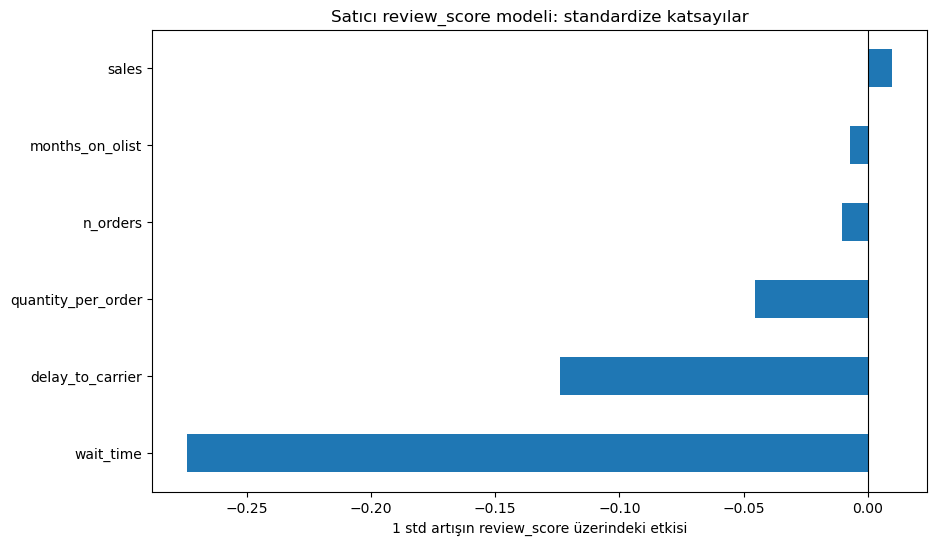

In [28]:
# YOUR CODE HERE
model.params.drop('Intercept').sort_values().plot.barh(figsize=(10, 6))
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Satıcı review_score modeli: standardize katsayılar')
plt.xlabel('1 std artışın review_score üzerindeki etkisi')
plt.show()

👉 Son olarak modelinizin performansını (`R-squared`) ve `residuals`'ı inceleyin

In [29]:
# YOUR CODE HERE
print(model.rsquared)
residuals = model.resid
print(residuals.describe())

0.19411317790429405
count    2.967000e+03
mean    -3.546727e-15
std      7.195315e-01
min     -3.491207e+00
25%     -2.635666e-01
50%      8.626812e-02
75%      4.463709e-01
max      3.740641e+00
dtype: float64


👉 Gerçek değerlendirme puanlarını ve modelin tahmin ettiği puanları aynı grafikte göstererek karşılaştırın.

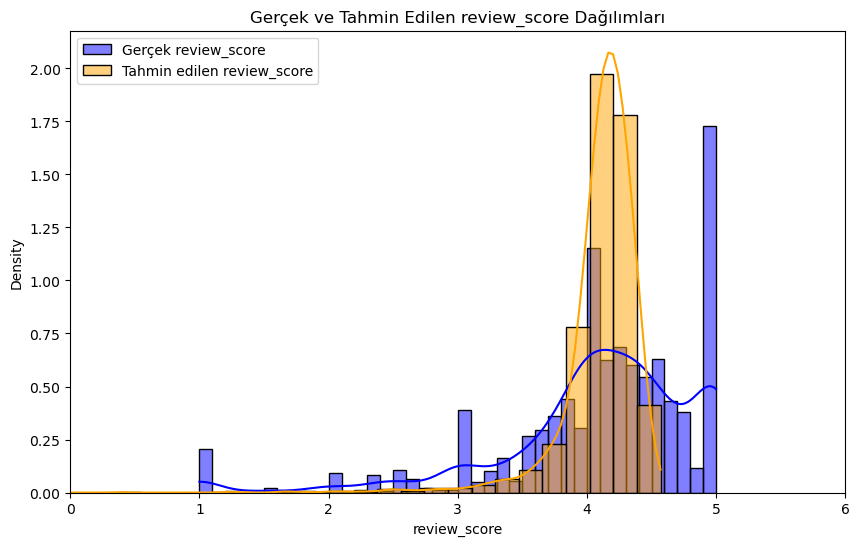

In [30]:
# YOUR CODE HERE
predicted_review_score = model.fittedvalues

plt.figure(figsize=(10, 6))

sns.histplot(sellers_standardized['review_score'], bins=40, color='blue', label='Gerçek review_score', kde=True, stat='density', alpha=0.5)

sns.histplot(predicted_review_score, bins=40, color='orange', label='Tahmin edilen review_score', kde=True, stat='density', alpha=0.5)

plt.xlim(0, 6)
plt.title('Gerçek ve Tahmin Edilen review_score Dağılımları')
plt.legend()
plt.show()

👉 Artıkları (residuals) görselleştirin

Text(0, 0.5, 'Yoğunluk')

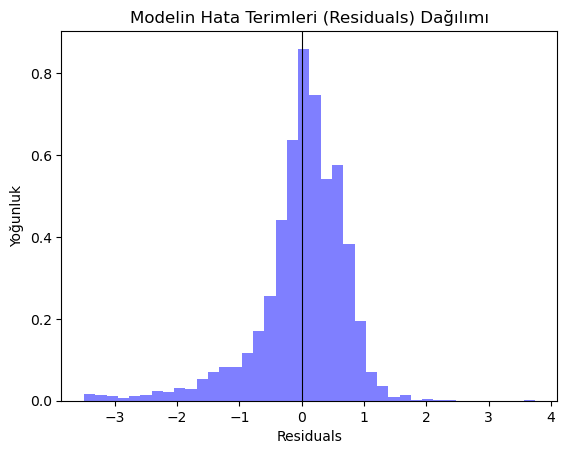

In [33]:
# YOUR CODE HERE
residuals.plot(kind='hist', bins=40, density=True, alpha=0.5, color='blue')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Modelin Hata Terimleri (Residuals) Dağılımı')
plt.xlabel('Residuals')
plt.ylabel('Yoğunluk')

<Axes: ylabel='Density'>

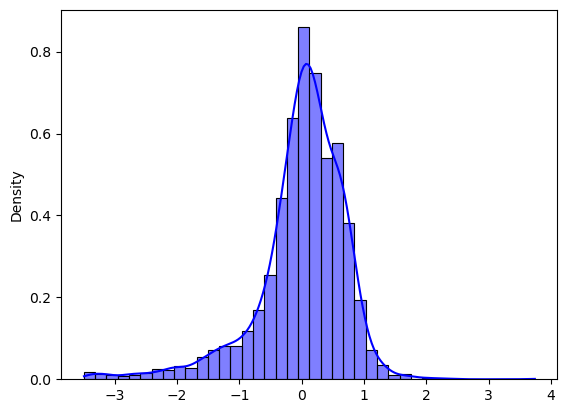

In [34]:
sns.histplot(residuals, bins=40, kde=True, stat='density', color='blue', alpha=0.5)

### (2.3) Analize `seller_state` bilgisini ekleyin

❓ Henüz `seller_state` bilgisini kullanmadık.  
- Sadece `seller_state`'lere karşı `review_score`'u regresyonla modelleyen yeni bir OLS oluşturun.
- `olist/utils.py` içinde sizin için yazılmış olan `return_significative_coef(model)` fonksiyonunu kullanarak anlamlı (significant) özellikleri analiz edin.
- `review_score` açısından en iyi eyaletler hangileri?

<details>
    <summary>- İpuçları -</summary>
        
⚠️ Dikkat, `seller_state` kategorik bir özelliktir. 
    
💡 Formülde kategorik değişkenleri belirtmek için `C(a_cat_feature)` kullanın. Bu, her benzersiz kategori için bir boolean değişken (`is_cat_feature_xx`) oluşturacaktır.

</details>

In [38]:
# YOUR CODE HERE
from olist.utils import return_significative_coef

sellers_standardized['seller_state'] = sellers_standardized['seller_state'].astype(object)
model_state = smf.ols('review_score ~ C(seller_state)', data=sellers_standardized).fit()
return_significative_coef(model_state)

,variable,p_value,coef
0,Intercept,0.003630,2.333333
16,C(seller_state)[T.RN],0.014751,2.142381
4,C(seller_state)[T.ES],0.011300,2.077548
8,C(seller_state)[T.MS],0.026098,1.954474
11,C(seller_state)[T.PB],0.025835,1.930556
9,C(seller_state)[T.MT],0.035051,1.889815
19,C(seller_state)[T.SC],0.022605,1.833534
14,C(seller_state)[T.PR],0.022771,1.829067
18,C(seller_state)[T.RS],0.024153,1.815430
5,C(seller_state)[T.GO],0.025828,1.810196


In [39]:
sellers['seller_state'].value_counts()

seller_state
SP    1768
PR     333
MG     236
SC     184
RJ     163
RS     125
GO      39
DF      30
ES      22
BA      18
CE      12
PE       9
PB       6
RN       5
MS       5
MT       4
RO       2
SE       2
PI       1
MA       1
AM       1
PA       1
Name: count, dtype: int64

☝️ Bazı eyaletlerin ortalama olarak diğerlerinden _anlamlı_ biçimde daha iyi değerlendirmelere sahip olduğu görülebilir.

🤔 Bu, daha düşük `quantity_per_order`, daha kısa `wait_time` veya `delay_to_carrier`'dan mı kaynaklanıyor? Yoksa elimizde olmayan başka faktörlerden mi?

❓ **`seller_state` etkisini diğerlerinden izole etmeye çalışın: OLS modelinize sürekli (continuous) diğer özellikleri ekleyin; `seller_state` artık istatistiksel olarak anlamlı olmayana kadar devam edin!**

In [40]:
# YOUR CODE HERE
model2 = smf.ols('review_score ~ C(seller_state) + quantity_per_order', data=sellers_standardized).fit()
return_significative_coef(model2)

,variable,p_value,coef
0,Intercept,0.003839,2.314894
16,C(seller_state)[T.RN],0.014251,2.149245
4,C(seller_state)[T.ES],0.010602,2.091851
8,C(seller_state)[T.MS],0.025722,1.955707
11,C(seller_state)[T.PB],0.025184,1.935439
9,C(seller_state)[T.MT],0.034219,1.894915
19,C(seller_state)[T.SC],0.020449,1.860625
14,C(seller_state)[T.PR],0.021326,1.845618
5,C(seller_state)[T.GO],0.023554,1.835668
18,C(seller_state)[T.RS],0.022467,1.834293


In [41]:
# YOUR CODE HERE
model3 = smf.ols('review_score ~ C(seller_state) + quantity_per_order + wait_time + delay_to_carrier', data=sellers_standardized).fit()
return_significative_coef(model3)

,variable,p_value,coef
0,Intercept,3.218613e-07,3.706197
22,quantity_per_order,6.193825e-04,-0.045408
24,delay_to_carrier,1.031439e-15,-0.120940
23,wait_time,5.036616e-72,-0.279082


In [42]:
# Yeterince siparişi olan ve ortalama puanı düşük satıcılar
dusuk_performans = sellers[(sellers['review_score'] < 3.5) & (sellers['n_orders'] >= 10)]

print(f"Düşük performanslı satıcı sayısı: {len(dusuk_performans)}")

dusuk_performans.sort_values('review_score')[
    ['seller_id', 'seller_state', 'n_orders', 'review_score',
     'share_of_one_stars', 'wait_time', 'delay_to_carrier']
].head(10)

Düşük performanslı satıcı sayısı: 84


,seller_id,seller_state,n_orders,review_score,share_of_one_stars,wait_time,delay_to_carrier
2919,4342d4b2ba6b161468c63a7e7cfce593,RJ,20,1.263158,0.894737,15.676088,0.000000
930,b1b3948701c5c72445495bd161b83a4c,SP,18,1.722222,0.777778,23.403023,9.374632
1928,973f21788dfab357250f69a8dcb7ddee,MG,10,2.000000,0.700000,21.206092,5.986722
2186,ffff564a4f9085cd26170f4732393726,SP,20,2.100000,0.650000,12.496233,0.000000
2742,1ca7077d890b907f89be8c954a02686a,SP,115,2.333333,0.535088,15.028811,0.000000
2626,fa74b2f3287d296e9fbd2cc80f2d1cf1,SP,11,2.363636,0.636364,30.380074,0.000000
1893,40db9e9aa57f7bb151bcda6b0f9bdbb7,PE,12,2.363636,0.545455,14.775632,0.000000
929,5bc55dbe2f12b6af6d83ed46023e0dc8,MG,17,2.411765,0.470588,12.996622,0.000000
2139,b5abf4f36adc043117b4fca82c22984c,DF,11,2.545455,0.454545,21.200986,7.710418
1652,ecccfa2bb93b34a3bf033cc5d1dcdc69,PR,15,2.571429,0.500000,35.133161,17.892721


In [43]:
sellers['dusuk_performans'] = (sellers['review_score'] < 3.5) & (sellers['n_orders'] >= 10)

sellers.groupby('dusuk_performans')[['wait_time', 'delay_to_carrier', 'quantity_per_order',
                                     'share_of_one_stars', 'n_orders']].mean()

,wait_time,delay_to_carrier,quantity_per_order,share_of_one_stars,n_orders
dusuk_performans,,,,,
False,11.977028,0.365345,1.155875,0.114338,33.270552
True,17.712853,1.082045,1.207516,0.345626,46.690476


☝️ Analize `wait_time` ekledikten sonra, 22 adet `is_seller_state_xx` dummy değişkeninin hiçbirinin istatistiksel olarak anlamlı olmadığı görüldü:

Küçük veri setimiz göz önüne alındığında (çoğu eyalette çok az sayıda satıcı var):
- "Bazı eyaletlerin, `wait_time` dışındaki nedenlerle doğal olarak diğerlerinden daha iyi olduğu" sonucuna _varamayız_.
- Başka bir deyişle, "`seller_state`'in `wait_time` dışında `review_score` üzerinde etkisi yoktur" hipotezini reddedemeyiz.

🏁 Tebrikler!

💾 Commit ve push yapın:
- `sellers.ipynb` not defterinizi
- ayrıca `seller.py` dosyanızı